In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import BaseMessage

c:\Users\Ryan\Miniconda3\envs\total\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import List, Dict, Any, Literal
from typing_extensions import Annotated, TypedDict
from langgraph.graph import MessagesState
from langgraph.types import Command
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import SystemMessage, HumanMessage , AIMessage

from backend.chatbot.prompts import supervisor_prompt

def merge_dicts(old, new): # i used this to let collected output gest updated before overwriting
    return {**old, **new}

class GraphState(MessagesState):
    remaining_agents: List[str]
    collected_outputs: Annotated[Dict[str, Any], merge_dicts]
    final_answer: str


class RouterState(TypedDict):
    next: str
    reason: str
    confidence: float


In [3]:
import os
from langchain_openai import ChatOpenAI
from user_context import first, second, third


# llm = ChatOpenAI(
#     model="deepseek-v4-flash",
#     api_key='sk-1666caf6a268456d8df5b5da9853d5d6',
#     base_url="https://api.deepseek.com",
#     temperature=0,
#     reasoning_effort="high",",

# llm = ChatOpenAI(
#     model="deepseek-v4-flash",
#     api_key="sk-1666caf6a268456d8df5b5da9853d5d6",
#     base_url="https://api.deepseek.com",
#     temperature=0,
#     reasoning_effort="high",
#     extra_body={
#         "thinking": {"type": "enabled"},
#         # "response_format": {"type": "json_object"} 
#     }
# )

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="deepseek-v4-flash",
    api_key="sk-1666caf6a268456d8df5b5da9853d5d6",
    base_url="https://api.deepseek.com",
    temperature=0,
    reasoning_effort="max",
    

    model_kwargs={
        "response_format": {
            "type": "json_object"
        },
    },

    extra_body={
        "thinking": {
            "type": "enabled"
        }
    }
)

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     base_url="https://api.gapgpt.app/v1",
#     api_key="sk-maGdVnAynciq7MyrhlnX6NrVYcPirPgNR1y8N5CcxglcEVWG",
#     model="gpt-5.4",
#     temperature=0
# )

In [4]:
llm.invoke(' json hi سلام')

AIMessage(content='{"greeting":"hi","arabic_greeting":"سلام"}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 186, 'prompt_tokens': 119, 'total_tokens': 305, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 171, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 119}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'e520f9af-d547-476c-bd14-b75214ae3f82', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe2f9-888e-75b2-b7c6-7c8c64990a56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 186, 'total_tokens': 305, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 171}})

### agent list

In [5]:

from backend.chatbot.prompts.attachment import prompt as attachment_prompt
from backend.chatbot.prompts.schema import prompt as  schema_prompt 
from backend.chatbot.prompts.clinical_disorder import prompt as clinical_disorder_prompt 
from backend.chatbot.prompts.personal_traits import prompt as personal_train_prompt 
from backend.chatbot.prompts.relational_pattern import prompt as relational_pattern_prompt
from backend.chatbot.prompts.functional_level import prompt as functional_level_prompt
from backend.chatbot.prompts.cognetive_distortion import prompt as cognitive_distortation_prompt
import json

def create_agent_node(llm  , prompt , node_name) :
    
    def agent(state:GraphState)-> Command[Literal['supervisor']]: 
        user_context = state["messages"][-1].content 
        
        prefix = f"USER_CONTEXT:\n{user_context}\n<END_USER_CONTEXT>\n"
        suffix = f"INSTRUCTION:\n{prompt}\n"

        instruction = prefix + suffix
        messages = [
            SystemMessage(content= instruction), 
            # HumanMessage(content = user_context)
        ]

        response = llm.invoke(messages) # router node 
        print('-'*50)
        print(f'agent {node_name}', response.response_metadata['token_usage'])
        print('-'*50)

        # updated_messages = state['messages'] + [
        #     AIMessage(content = response.content , name = node_name)
        # ]
        try: 
            data = json.loads(response.content)
            # print('-'*50)
            # print(f'agent {node_name} called , response is :',data)
            # print('-'*50)

        except: 
            print('json error raw output is ' , response.content)

        return Command(
            update={
                "collected_outputs": {
                    node_name: data
                }
            },
            goto="supervisor"
        )
    return agent

attachment_agent = create_agent_node(llm, attachment_prompt , node_name = 'atthchment')
schema_agent = create_agent_node(llm, schema_prompt , node_name = 'schema')
clinical_disorder_agent = create_agent_node(llm, clinical_disorder_prompt , node_name = 'clinical_disorder')
personal_trait_agent = create_agent_node(llm, personal_train_prompt , node_name = 'personal_trait')
relational_pattern_agent = create_agent_node(llm, relational_pattern_prompt , node_name = 'relational_pattern')
functional_level_agent = create_agent_node(llm, functional_level_prompt , node_name = 'functional_level')
cognitive_distortion_agent = create_agent_node(llm, cognitive_distortation_prompt , node_name = 'cognitive_distortion')

# from tenacity import retry, stop_after_attempt, wait_exponential

# @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
# def safe_llm_invoke(prompt):
#     return llm.invoke(prompt)

(با ورودی ~1850 و خروجی ~400)


### planner and executor code 

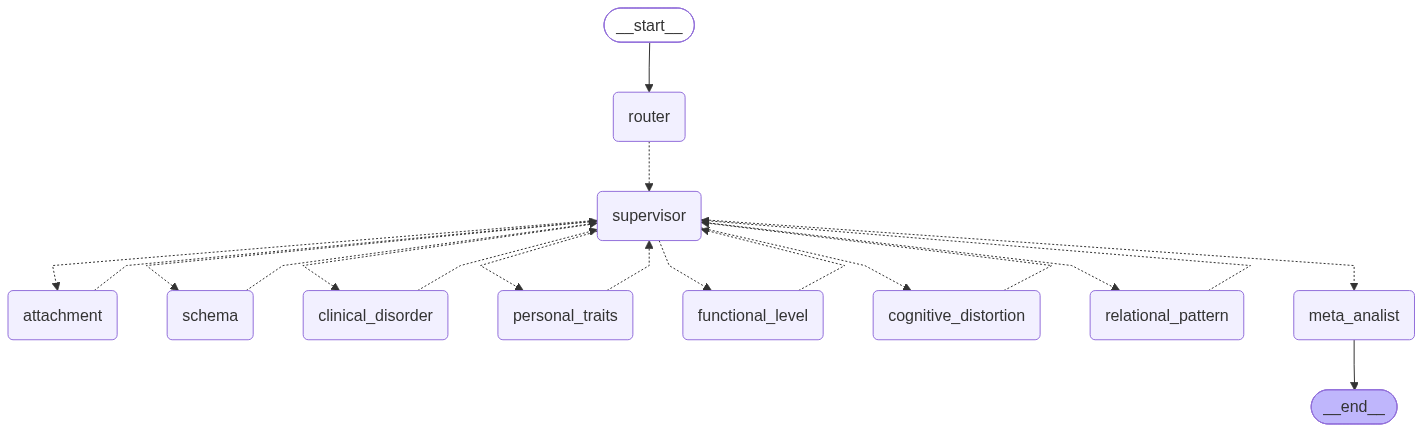

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	supervisor(supervisor)
	attachment(attachment)
	schema(schema)
	clinical_disorder(clinical_disorder)
	personal_traits(personal_traits)
	functional_level(functional_level)
	cognitive_distortion(cognitive_distortion)
	relational_pattern(relational_pattern)
	meta_analist(meta_analist)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	attachment -.-> supervisor;
	clinical_disorder -.-> supervisor;
	cognitive_distortion -.-> supervisor;
	functional_level -.-> supervisor;
	personal_traits -.-> supervisor;
	relational_pattern -.-> supervisor;
	router -.-> supervisor;
	schema -.-> supervisor;
	supervisor -.-> attachment;
	supervisor -.-> clinical_disorder;
	supervisor -.-> cognitive_distortion;
	supervisor -.-> functional_level;
	supervisor -.-> meta_analist;
	supervisor -.-> personal_traits;
	supervisor -.-> relational_pattern;
	supervisor -.-> schema;
	meta_analist --> __e

In [ ]:
from typing import List, Dict, Any
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, END
from langgraph.types import Command
from langgraph.graph import MessagesState
from backend.chatbot.prompts.meta_analist import prompt as meta_analist_prompt
from backend.chatbot.prompts.supervisor_prompt import prompt as supervisor_prompt
from user_context import first, second, third
import json

def router_node(state: GraphState) -> Command[
       Literal['supervisor']
    ]:
        remaining_agents = state.get("remaining_agents", [])
        if not remaining_agents:
            return Command(goto="meta_analist")

        options = remaining_agents 
        
        system_prompt = (
              supervisor_prompt + "\n\nAvailable agents: " + ", ".join(options)
            )
        
        user_context = state["messages"][-1].content
        
        prefix = f"USER_CONTEXT:\n{user_context}\n<END_USER_CONTEXT>\n"
        suffix = f"INSTRUCTION:\n{system_prompt}\n"

        instruction = prefix + suffix
        messages = [
            SystemMessage(content= instruction), 
            # HumanMessage(content = user_context)
        ]
   

        response = llm.invoke(messages)
        # print(response.response_metadata['token_usage'])

        data = json.loads(response.content)
        print(data)
        print('*'*50)
        print("router node call" , response.response_metadata['token_usage'])
        print('*'*50)
        return Command(
            goto = 'supervisor',
            update = {
                'remaining_agents' : data['selected_agents'],
                'collected_outputs': {} 
            }
        )


def supervisor_node(state: GraphState) -> Command[
    Literal[
        "attachment",
        "schema",
        "clinical_disorder",
        "personal_traits",
        "functional_level",
        "cognitive_distortion",
        "relational_pattern",
        "meta_analist", ]
        ]:
    remaining_agents = state.get("remaining_agents", [])

    if not remaining_agents:
        return Command(goto="meta_analist")

    next_agent = remaining_agents[0]
    # print('/'*50)
    # print(f'supervisor node is called , next_agent is' , next_agent)
    # print('/'*50)
    return Command(
        goto=next_agent,
        update={
            "remaining_agents": remaining_agents[1:],
            # 'remaining_agents' : []  
        },
    )

def meta_analist_node(state: GraphState) -> Command:
    outputs = state.get("collected_outputs", {})
    client_message = state["messages"][-1].content
    payload = {
        "USER_CONTEXT": client_message,
        "agent_outputs": outputs,
    }

    prefix = f"USER_CONTEXT:\n{payload['USER_CONTEXT']}\n<END_USER_CONTEXT>\n"
    agents_output = f"agents_output : \n {payload['agent_outputs']}\n <END_AGENTS_OUTPUT>\n"
    suffix = f"INSTRUCTION:\n{meta_analist_prompt}\n"

    instruction = prefix + agents_output + suffix
    messages = [
        SystemMessage(content= instruction), 
        # HumanMessage(content = user_context)
    ]

    response = llm.invoke(messages)
    try: 
        result = json.loads(response.content)
        print('*'*50)
        print('meta analist' , response.response_metadata['token_usage'])
        print('*'*50)
      
    except: 
        print('error happening , raw data ', response.content)

    return Command(
        goto=END,
        update={"final_answer": result},
    )


builder = StateGraph(GraphState)

builder.add_node("router", router_node)
builder.add_node("supervisor", supervisor_node)

agent_info = {
    "attachment" : attachment_prompt,
    "schema" : schema_prompt,
    "clinical_disorder" : clinical_disorder_prompt,
    "personal_traits" : personal_train_prompt,
    "functional_level" : functional_level_prompt,
    'cognitive_distortion' : cognitive_distortation_prompt,
    'relational_pattern' : relational_pattern_prompt
}

for name , prompt in agent_info.items():
    builder.add_node(name, create_agent_node(llm, prompt , node_name = name))

builder.add_node("meta_analist", meta_analist_node)

builder.set_entry_point("router")

graph = builder.compile()

# result = graph.invoke(
#     {
#         "messages": [],
#     }
# )

from IPython.display import Image, display

img = graph.get_graph().draw_mermaid_png()
display(Image(img))
print(graph.get_graph().draw_mermaid())

In [7]:
import os
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI



# --- 1. Define two DIFFERENT system prompts ---
system_prompt_1 = """
u are a clinical psychologist. Analyze the patient's symptoms.
Focus on anxiety disorder diagnosis.
""" * 3  # Make it long enough to exceed caching thresholds

system_prompt_2 = """
u are a cognitive-behavioral therapist. Analyze the patient's thought patterns.
Focus on identifying cognitive distortions.
""" * 3  # Make it long enough to exceed caching thresholds

# --- 2. Define an IDENTICAL, long user message ---
long_user_message = """
he user message is :  json patient has been experiencing persistent anxiety symptoms for the past 6 months. 
They report difficulty sleeping, racing thoughts, and frequent feelings of dread. 
Their work performance has declined, and they've withdrawn from social activities. 
The patient has no history of substance abuse or previous psychiatric treatment. 
Family history includes maternal anxiety disorder. The patient is motivated for treatment
but expresses skepticism about medication. They prefer talk therapy approaches. 
The patient's physical health appears stable with no major medical conditions. 
Recent blood work was unremarkable. The patient reports occasional panic attacks,
lasting approximately 10-15 minutes, characterized by heart palpitations and shortness of breath.
""" * 2  # Make it long enough to exceed 64 tokens

# --- 3. Execute the test sequence ---
print("="*60)
print("TEST: Same user message, DIFFERENT system prompts")
print("="*60)

# Request 1: System Prompt 1 + User Message (should be a CACHE MISS)
print("\n[Request 1] System Prompt 1 + User Message")
res1 = llm.invoke([
    SystemMessage(content=long_user_message + system_prompt_1),
])
print(f"  Cache Miss Tokens: {res1.response_metadata['token_usage']['prompt_cache_miss_tokens']}")
print(f"  Cache Hit Tokens:  {res1.response_metadata['token_usage']['prompt_cache_hit_tokens']}")

# Request 2: System Prompt 2 (DIFFERENT!) + Same User Message (should be a CACHE MISS)
print("\n[Request 2] System Prompt 2 (DIFFERENT!) + Same User Message")
res2 = llm.invoke([
    SystemMessage(content=long_user_message + system_prompt_2),
])
print(f"  Cache Miss Tokens: {res2.response_metadata['token_usage']['prompt_cache_miss_tokens']}")
print(f"  Cache Hit Tokens:  {res2.response_metadata['token_usage']['prompt_cache_hit_tokens']}")



TEST: Same user message, DIFFERENT system prompts

[Request 1] System Prompt 1 + User Message
  Cache Miss Tokens: 65
  Cache Hit Tokens:  384

[Request 2] System Prompt 2 (DIFFERENT!) + Same User Message
  Cache Miss Tokens: 77
  Cache Hit Tokens:  384


In [8]:
from backend.chatbot.prompts import emotional_state, personal_traits
from user_context import fifth

state = {
    "messages": [
        HumanMessage(content=fifth) 
    ],
    "remaining_agents": [
        "schema",
        "attachment",
        "clinical_disorder",
        "cognitive_distortion",
        "functional_level",
        "personal_traits",
        "relational_pattern",
    ],
    "collected_outputs": {},
    "final_answer": None,  
}

result  = graph.invoke(state)
result

# result = schema_agent(state)

{'selected_agents': ['attachment', 'schema', 'clinical_disorder', 'cognitive_distortion', 'functional_level', 'personal_traits', 'relational_pattern']}
**************************************************
router node call {'completion_tokens': 5553, 'prompt_tokens': 7266, 'total_tokens': 12819, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 5516, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 7168}, 'prompt_cache_hit_tokens': 7168, 'prompt_cache_miss_tokens': 98}
**************************************************
--------------------------------------------------
agent attachment {'completion_tokens': 12143, 'prompt_tokens': 7785, 'total_tokens': 19928, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 9746, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 7680}, '

{'messages': [HumanMessage(content='\n{\n  "conversation": [\n    {\n      "role": "user",\n      "content": "من هفت ساله ازدواج کردم ، یدونه بچه یه ساله دارم ، قبل از ازدواج سه سال با شوهرم دوست بودم ، خیلی رابطه ی خوبی بود ، ولی بعد ازینکه ازدواج کردم مشکلاتم شروع شد ، من قبلا شاد بودم ولی الان همش ناراحتی و افسردگی دارم ، از بعد از تولد بچم تازه ناراحتیام بیشترم شده"\n    },\n    {\n      "role": "assistant",\n      "content": "گفتی قبل از ازدواج سه سال با هم دوست بودید و رابطه\u200cتان خیلی خوب بود. بعد از ازدواج، اولین باری که حس کردی مشکلی شروع شده، چه اتفاقی افتاد؟"\n    },\n    {\n      "role": "user",\n      "content": "خب شوهرم دیگ سر کار نرفت ، و از پس اندازش و سرمایه هایی که داشت زندگی رو می چرخوندیم ، بیشتر تو خونه بودو کنار هم بودیم ، و حضور پدر مادرشم توی واحد بغل باعث میشد همه ی کاراشونو از ما بخوان ،  و انگار همه ی کارهام با اجازه ی خانوادش باید انجام میشد"\n    },\n    {\n      "role": "assistant",\n      "content": "انگار دو تا تغییر بزرگ همزمان اتفاق افتاده: یکی این

In [9]:
result

{'messages': [HumanMessage(content='\n{\n  "conversation": [\n    {\n      "role": "user",\n      "content": "من هفت ساله ازدواج کردم ، یدونه بچه یه ساله دارم ، قبل از ازدواج سه سال با شوهرم دوست بودم ، خیلی رابطه ی خوبی بود ، ولی بعد ازینکه ازدواج کردم مشکلاتم شروع شد ، من قبلا شاد بودم ولی الان همش ناراحتی و افسردگی دارم ، از بعد از تولد بچم تازه ناراحتیام بیشترم شده"\n    },\n    {\n      "role": "assistant",\n      "content": "گفتی قبل از ازدواج سه سال با هم دوست بودید و رابطه\u200cتان خیلی خوب بود. بعد از ازدواج، اولین باری که حس کردی مشکلی شروع شده، چه اتفاقی افتاد؟"\n    },\n    {\n      "role": "user",\n      "content": "خب شوهرم دیگ سر کار نرفت ، و از پس اندازش و سرمایه هایی که داشت زندگی رو می چرخوندیم ، بیشتر تو خونه بودو کنار هم بودیم ، و حضور پدر مادرشم توی واحد بغل باعث میشد همه ی کاراشونو از ما بخوان ،  و انگار همه ی کارهام با اجازه ی خانوادش باید انجام میشد"\n    },\n    {\n      "role": "assistant",\n      "content": "انگار دو تا تغییر بزرگ همزمان اتفاق افتاده: یکی این

In [10]:
result.update['collected_outputs']['schema']['scores']


TypeError: 'builtin_function_or_method' object is not subscriptable

In [ ]:
summary = result.update['collected_outputs']['schema']['summary']
print(summary)

In [ ]:
result.update['collected_outputs']['schema']['evidence']

In [ ]:
result['collected_outputs'].keys()